In [ ]:
#Imports


In [2]:
import sys,os
os.environ['MKL_NUM_THREADS'] = '4' # set number of MKL threads to run in parallel
from quspin.operators import hamiltonian,quantum_operator
from quspin.basis import spin_basis_1d
from numpy.random import uniform,seed
from joblib import delayed,Parallel

from itertools import combinations
from functools import partial
import numpy as np
import gc
import pickle
from time import time
from quspin.tools.measurements import diag_ensemble
from quspin.tools.evolution import ED_state_vs_time
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, show, figure, xlabel, ylabel, xscale, yscale, legend, loglog,title,show,imshow,colorbar,legend,scatter
from numpy import pi, exp, log, sin , cos, tan, log, array
import quspin
timestamp = time()
from scipy.optimize import minimize_scalar
# dat and alphasearch already defined
import warnings
warnings.filterwarnings("ignore")
# dat and alphasearch already defined



In [1]:
###Functions
def timer(timestamp):
    #Timer Function
    print("time =", time()-timestamp)
    return

def fin_string(ns,s): #ns = length of string s = operator
    #Max string length
    if ns>L:
        ns=L
    else:
        pass
    
    
    def linears(start,m):
        #Find all indices in string
        ind=[i%L for i in range(start,start+ns)]
     #All combinations
        perm=list(combinations(ind,m))
      #Add each coupling to operator
        for j in range(len(perm)):
#            S_temp=[((-1)**m)*(2**m)/(L*(2**ns))] ########### Down #
            S_temp=[1/(1*(2**ns))] ###################### Up
            for i in range(len(perm[j])):
                S_temp.append(perm[j][i])
        ##Saving Couplin gs lists
            if j==0: 
                S_temp_2=[S_temp]
            else: 
                S_temp_2.append(S_temp)
        return S_temp_2
    #List to store orders of interaction
    o_type=np.empty(ns,dtype=object)
    
    for i in range(ns):
        #ex: "z"*2= "zz"
        o_type[i]=s*(i+1)

    #Iterate over each Site
    for k in range(1):
        #Iterate over different string lengths
      for i in range(ns):
          #First item defines list
          if k==0 and i==0:
              #example: i = 0 operator_list = [['x', linears(k,1)]]
              operator_list=[[o_type[i],linears(k,i+1)]]
          else:
              operator_list.append([o_type[i],linears(k,i+1)])
    S_temp_1 = [[(1/((ns*2**ns))), i] for i in range(ns)]
    #S_temp_1 = [[(1/((ns*2**(ns)))), 1] ]
    operator_list.append(["I",S_temp_1])
    operator_dict=dict(S=operator_list)
    O = quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
    #print(operator_list)
    return array(O.todense())

def commute(A,B):
    return A@B-B@A
def diagonalize(op,basis):
    return basis.T@op@basis
def norm(op):
    return np.abs(op)/np.max(np.abs(op))

(0.49999999999999745+0j)
(0.5000000000000027+0j)
(0.5000000000000024+0j)
(0.49999999999999734+0j)
(0.4999999999999966+0j)
(0.5000000000000023+0j)
(0.4999999999999995+0j)
(0.5000000000000199+0j)
(0.5000000000000026+0j)
(0.500000000000004+0j)
(0.49999999999997147+0j)
(0.500000000000001+0j)
(0.49999999999999084+0j)
(0.49999999999999906+0j)
(0.5000000000000085+0j)
(0.5000000000000012+0j)
(0.5000000000000009+0j)
(0.4999999999999966+0j)
(0.5000000000000001+0j)
(0.5000000000000013+0j)
(0.5000000000000002+0j)
(0.4999999999999986+0j)
(0.5000000000000002+0j)
(0.49999999999999967+0j)
(0.49999999999999284+0j)
(0.5000000000000002+0j)
(0.4999999999999996+0j)
(0.5+0j)
(0.5000000000000053+0j)
(0.49999999999999994+0j)
(0.5000000000000047+0j)
(0.5000000000000003+0j)
(0.5000000000000002+0j)
(0.5000000000000001+0j)
(0.5000000000000051+0j)
(0.5000000000000095+0j)
(0.5000000000000011+0j)
(0.49999999999999856+0j)
(0.49999999999999967+0j)
(0.49999999999999006+0j)
(0.4999999999999936+0j)
(0.5000000000000026+0j

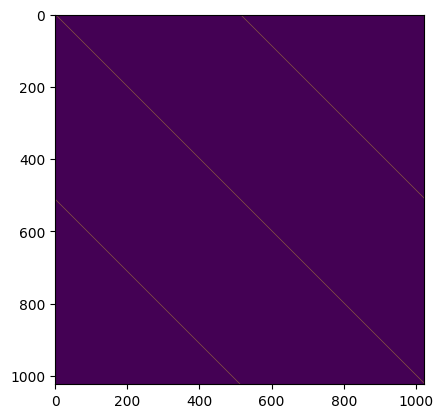

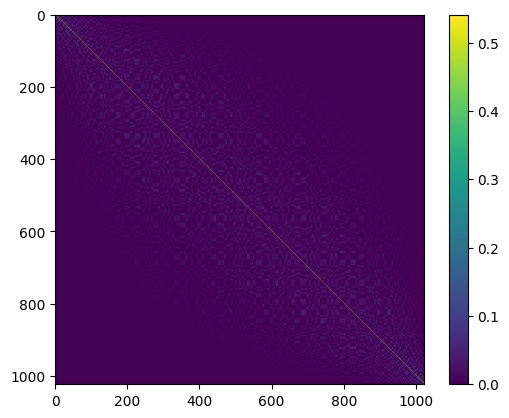

In [5]:
#Hamiltonian
###### Model parameters
#Length of chain
L = 10
J = 1
h0 = 0
basis = spin_basis_1d(L, pauli = -1)

NN_sigma_x = [ [-J, i, (i+1)%L] for i in range(L)]
sigma_z = [ [-1, i] for i in range(L)]

#Define the static H (that doesn't change)
static_H = [ ["xx", NN_sigma_x] ] 
#The z field is the quench
Quenching_H = [["z", sigma_z]]

#Define operator dictionary
operator_dict = dict(H0= static_H, Quench = Quenching_H)
#Build Hamiltonian
H = quantum_operator(operator_dict, basis=basis, check_herm= False, check_symm = False)
#Define Parameters
params_dict = dict( H0=1, Quench=h0)
#Build H0
#H = H.tohamiltonian(params_dict)
#Find eigenvalues
E,V = np.linalg.eigh(H.todense())
#Convert matrix to array
V = np.array(V)
#H = array(H.todense())
p1 = fin_string(1,"x")
for i in range(len(E)):
    v = V[:,i]
    print(np.vdot(v,p1@v))
imshow(np.abs(p1))
show()
imshow(np.abs(V.T@p1@V))
colorbar()

In [139]:
from quspin.tools.evolution import evolve

# quench time
tau = 10.0

# time-dependent Hamiltonian callback
def H_t(t, psi, H0, Quench, tau):
    h_t = 1.0 - t/tau
    return (H0 + h_t*Quench).dot(psi)

# split static pieces once
H0_mat     = H.tohamiltonian(dict(H0=1, Quench=0)).tocsr()
Quench_mat = H.tohamiltonian(dict(H0=0, Quench=1)).tocsr()

# initial state: ground state at t=-tau (i.e. h=1-(-tau)/tau=2)
h_init = 2.0
H_init = (H0_mat + h_init*Quench_mat).todense()
E0, V0 = np.linalg.eigh(H_init)
psi0 = np.array(V0[:,0])        # ground state

# time grid
times = np.linspace(-tau, tau, 401)

# evolve
psi_t = evolve(
    psi0,
    times[0],
    times,
    H_t,
    f_params=(H0_mat, Quench_mat, tau),
    iterate=False
)  # psi_t has shape (len(times), dim)


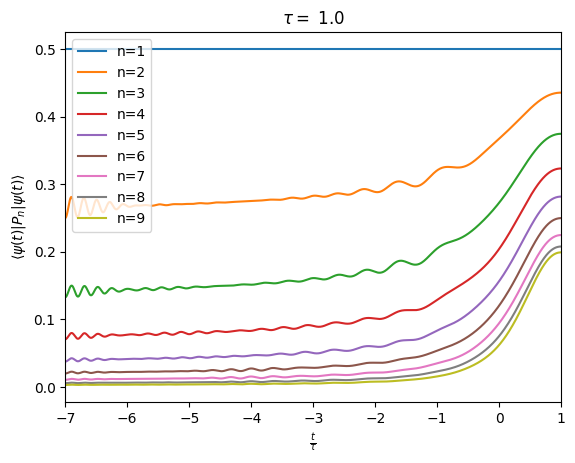

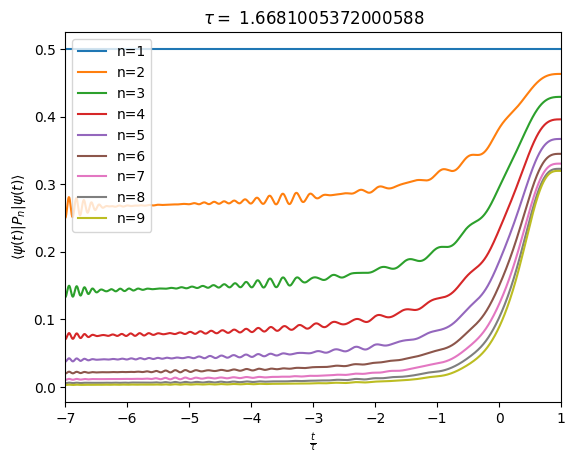

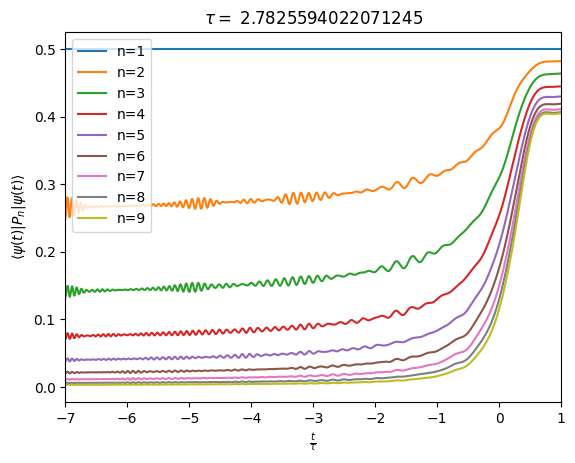

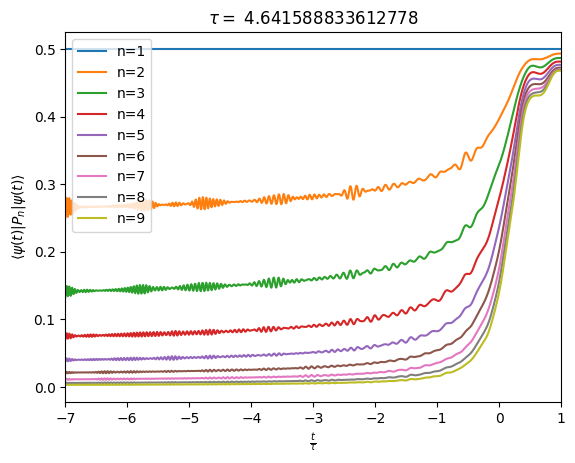

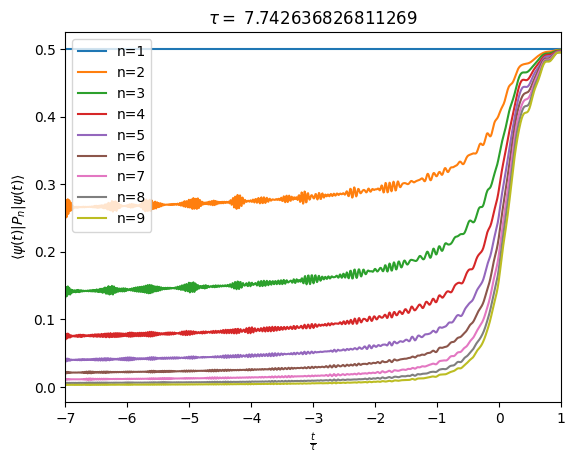

KeyboardInterrupt: 

In [ ]:
import numpy as np
from quspin.tools.evolution import evolve
taus = np.logspace(0,2,10)
ns = np.arange(1,L)
P0 = fin_string(1,"z")
for tau in taus:

    # build TWO fixed sparse matrices once
    H0_mat     = H.tohamiltonian(dict(H0=1, Quench=0)).tocsr()
    Quench_mat = H.tohamiltonian(dict(H0=0, Quench=1)).tocsr()

    # time-dependent Schrödinger RHS: dψ/dt = -i H(t) ψ
    def schrodinger_rhs(t, psi, H0_mat, Quench_mat, tau):
        h_t =  1-t/tau
        return -1j * (H0_mat + h_t*Quench_mat).dot(psi)

    # initial state = ground state of H(t=-tau) where h(-tau)=2
    H_init = (H0_mat +8*Quench_mat).toarray()          # ndarray (256,256), not numpy.matrix
    E0, V0 = np.linalg.eigh(H_init)                        # ndarrays
    psi0   =P0@V0[:, 0].copy()                               # ndarray (256,)
    psi0 = psi0/np.linalg.norm(psi0)

    # evolve from t=-tau to t=+tau

    times = np.linspace(-tau*7, tau, 1000)
    psi_t = evolve(
        psi0,
        times[0],
        times,
        schrodinger_rhs,
        f_params=(H0_mat, Quench_mat, tau),
        iterate=False
    )

    # make psi_t an ndarray with shape (256, 401)
    psi_t = np.asarray(psi_t)
    if psi_t.shape == (len(times), psi0.size):
        psi_t = psi_t.T  # convert to (256,401) if returned as (401,256)
    for n in ns:
        p = fin_string(n,"x")
    # overlaps <psi0|psi(t)> for all t (plain dot products, no matrix type)
        overlap_t = array([np.vdot(psi_t[:,j],p@psi_t[:,j]) for j in range(len(times))])
    # example: overlap at t=0
    H_init = (H0_mat + 9.0*Quench_mat).toarray()
    E0, V0 = np.linalg.eigh(H_init)
    psi0   = V0[:, 0].copy()

    # evolve
    times = np.linspace(-8*tau, tau, 1000)

        plot(times/tau,(overlap_t),label=f"n={n}")
    title(rf"$\tau = $ {tau}")
    xlabel(r"$\frac{t}{\tau}$")
    ylabel(r"$\langle \psi(t) | P_n | \psi(t)\rangle$")
    legend()
    plt.xlim(times[0]/tau,times[-1]/tau)
    #yscale("log")
    show()




In [ ]:
import numpy as np
from quspin.tools.evolution import evolve
from tqdm import tqdm
taus = np.logspace(-2, 1.5, 20)
ns   = np.arange(2, L)

# allocate: rows = n, cols = tau
defects = np.zeros((len(ns), len(taus)), dtype=float)

# build fixed pieces once (outside tau-loop)
H0_mat     = H.tohamiltonian(dict(H0=1, Quench=0)).tocsr()
Quench_mat = H.tohamiltonian(dict(H0=0, Quench=1)).tocsr()

def schrodinger_rhs(t, psi, H0_mat, Quench_mat, tau):
    h_t = 1.0 - t/tau
    return -1j * (H0_mat + h_t*Quench_mat).dot(psi)

for it, tau in enumerate(tqdm(taus)):

    # initial state at g=9
    H_init = (H0_mat + 9.0*Quench_mat).toarray()
    E0, V0 = np.linalg.eigh(H_init)
    psi0   = V0[:, 0].copy()

    # evolve
    times = np.linspace(-8*tau, tau, 1000)
    psi_t = evolve(
        psi0,
        times[0],
        times,
        schrodinger_rhs,
        f_params=(H0_mat, Quench_mat, tau),
        iterate=False
    )

    psi_t = np.asarray(psi_t)
    if psi_t.shape == (len(times), psi0.size):
        psi_t = psi_t.T  # (dim, Nt)

    psi_final = psi_t[:, -1]

    # measure defects for all n
    for in_, n in enumerate(ns):
        p = fin_string(n, "x")
        defects[in_, it] = 0.5 - np.vdot(psi_final, p @ psi_final)

# defects has shape (len(ns), len(taus))


100%|██████████| 20/20 [01:08<00:00,  3.40s/it]


[]

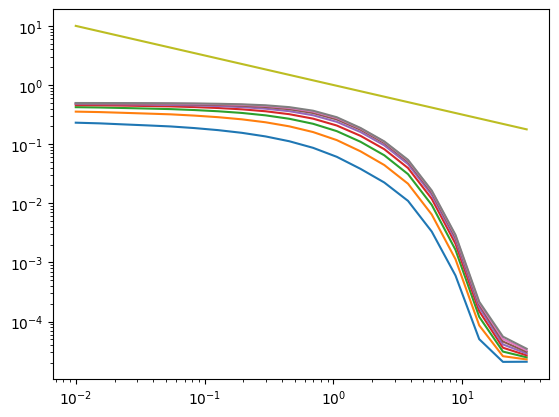

In [133]:
plot(taus,defects.T)
plot(taus,taus**(-1/2))
loglog()